GROUP 8
ECE 310 Wireless Communication

In [ ]:
!pip install torch torchvision torchaudio torch-geometric scikit-learn matplotlib -q

CLEAN SCM-GNN PIPELINE (Colab compatible)

In [ ]:
#!pip install -q pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv torch_geometric -f https://data.pyg.org/whl/torch-2.1.0+cu121.html

import numpy as np, math, time
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import ChebConv, SAGPooling, global_mean_pool, global_max_pool

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cpu


SCM-GNN (existing pipeline)- Importing modules



In [ ]:
import numpy as np, math, time
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import ChebConv, SAGPooling, global_mean_pool, global_max_pool

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


User Enable Parameters

In [ ]:
dat_path = "/content/Final_5dB.dat"   # change if needed
dtype = np.float32

sample_size = 100
num_signal_windows = 800
num_noise_windows  = 800
snr_db = -7
zeta = 8
top_k = 8
use_imag = True

batch_size = 200
epochs = 50
lr = 1e-3
weight_decay = 5e-4

#load  .dat
raw = np.fromfile(dat_path, dtype=dtype).reshape(-1)
raw = raw[np.logical_and(raw > 1e-7, raw < 1)]
print("Loaded samples:", raw.shape)

AWGN or windowing

In [ ]:
def bandpower(x): return np.mean(x**2)
def awgn(x, snr_db):
    noise = np.random.randn(*x.shape)
    snr_lin = 10**(snr_db/10)
    var_signal = snr_lin * bandpower(noise)
    x_norm = math.sqrt(var_signal) * (x / math.sqrt(bandpower(x)))
    return x_norm + noise

def create_windows(signal, num_windows, sample_size, snr_db=None):
    if snr_db is not None:
        sig = signal[:num_windows*sample_size].reshape(-1)
        sig = awgn(sig, snr_db)
    else:
        sig = np.random.randn(num_windows*sample_size)
    wins = [sig[i*sample_size:(i+1)*sample_size].copy() for i in range(num_windows)]
    return np.array(wins)

signal_windows = create_windows(raw, num_signal_windows, sample_size, snr_db)
noise_windows  = create_windows(raw, num_noise_windows, sample_size, snr_db=None)
print("Signal windows:", signal_windows.shape, "Noise windows:", nois

Computing time delay covariance

In [ ]:
def compute_cov(window, zeta):
    N = len(window)
    denom = N - (zeta - 1)
    R = np.zeros((zeta, zeta), dtype=complex)
    for tau1 in range(zeta):
        for tau2 in range(zeta):
            s = 0
            for t in range(zeta-1, N):
                v1 = window[t-tau1]
                v2 = window[t-tau2]
                s += v1 * np.conjugate(v2)
            R[tau1, tau2] = s / denom
    return R

Element-level graph builder used by SCM-GNN

In [ ]:
def covariance_to_graph(R, top_k=8, use_imag=True):
    zeta = R.shape[0]
    Q = zeta*zeta
    feats = []
    for r in range(zeta):
        for c in range(zeta):
            val = R[r,c]
            if use_imag:
                feats.append([np.real(val), np.imag(val)])
            else:
                feats.append([np.real(val)])
    X = np.array(feats, dtype=np.float32)
    norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
    Xn = X / norms
    S = Xn @ Xn.T
    np.fill_diagonal(S, 0)
    edge_src, edge_dst = [], []
    for i in range(Q):
        k = min(top_k, Q-1)
        neigh_idx = np.argsort(-S[i])[:k]
        for j in neigh_idx:
            edge_src.append(i); edge_dst.append(int(j))
            edge_src.append(int(j)); edge_dst.append(i)
    edge_index = torch.tensor([edge_src, edge_dst], dtype=torch.long)
    x = torch.tensor(X, dtype=torch.float)
    return Data(x=x, edge_index=edge_index)

Graphs dataset for SCM-GNN

In [ ]:
graphs = []
for w in signal_windows:
    g = covariance_to_graph(compute_cov(w, zeta), top_k=top_k, use_imag=use_imag)
    g.y = torch.tensor([1], dtype=torch.long); graphs.append(g)
for w in noise_windows:
    g = covariance_to_graph(compute_cov(w, zeta), top_k=top_k, use_imag=use_imag)
    g.y = torch.tensor([0], dtype=torch.long); graphs.append(g)
print("Total graphs:", len(graphs))

Split + dataloader

In [ ]:
perm = np.random.permutation(len(graphs))
split = int(0.8 * len(graphs))
train_graphs = [graphs[i] for i in perm[:split]]
test_graphs  = [graphs[i] for i in perm[split:]]
train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_graphs, batch_size=batch_size)
print("Train graphs:", len(train_graphs), "Test graphs:", len(test_graphs))

SCM-GNN model (element-level)

In [ ]:
class SCMGNN(nn.Module):
    def __init__(self, in_features, hidden=32, K=3):
        super().__init__()
        self.lin = nn.Linear(in_features, hidden)
        self.bn0 = nn.BatchNorm1d(hidden)
        self.conv = ChebConv(hidden, hidden, K)
        self.bn1 = nn.BatchNorm1d(hidden)
        self.pool = SAGPooling(hidden, ratio=0.5)
        self.fc1 = nn.Linear(hidden*2, 32)
        self.fc2 = nn.Linear(32, 2)
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.bn0(self.lin(x)))
        x = F.relu(self.bn1(self.conv(x, edge_index)))
        # SAGPooling safe call
        try:
            x, edge_index, batch = self.pool(x, edge_index, batch=batch)
        except:
            x, edge_index, _, batch, _, _ = self.pool(x, edge_index, None, batch)
        xm = global_mean_pool(x, batch)
        xM = global_max_pool(x, batch)
        h = torch.cat([xm, xM], dim=1)
        h = F.relu(self.fc1(h))
        return self.fc2(h)

in_feats = train_graphs[0].x.shape[1]
scm_gnn = SCMGNN(in_feats).to(device)
opt_scm = torch.optim.Adam(scm_gnn.parameters(), lr=lr, weight_decay=weight_decay)


Training Helpers

In [ ]:
def train_epoch(model, loader, optimizer):
    model.train()
    total = 0.0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch)
        loss = F.cross_entropy(out, batch.y.view(-1))
        loss.backward(); optimizer.step()
        total += loss.item() * batch.num_graphs
    return total / len(loader.dataset)

def eval_model(model, loader):
    model.eval()
    ys=[]; probs=[]
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch)
            p = F.softmax(out, dim=1)[:,1].cpu().numpy()
            ys.extend(batch.y.view(-1).cpu().numpy().tolist())
            probs.extend(p.tolist())
    return np.array(ys), np.array(probs)

# quick train (you can run full epochs later)
print("SCM-GNN ready. Run training in Cell 4 (comparison cell) to train all models together.")


SCM-PatchGNN (patch-based hierarchical model)

In [ ]:
# -------------------- CELL 2: SCM-PatchGNN (patch-based hierarchical model) --------------------
import numpy as np, torch
from torch_geometric.data import Data

# Parameters for patch model (can reuse cell1 params)
patch_size_blocks = 2   # number of SCM elements per patch side (zeta should be divisible)
pool_ratio1 = 0.6
pool_ratio2 = 0.5

# Reuse compute_cov from Cell1. Define patch extraction & patch graph builder:
def Ry_to_patches(Ry, patch_size_blocks=2, use_imag=True):
    H = Ry.shape[0]
    assert H % patch_size_blocks == 0, "Ry size must be divisible by patch_size_blocks"
    P = H // patch_size_blocks
    patches = []
    for r in range(P):
        for c in range(P):
            r0 = r*patch_size_blocks; r1 = (r+1)*patch_size_blocks
            c0 = c*patch_size_blocks; c1 = (c+1)*patch_size_blocks
            patch = Ry[r0:r1, c0:c1]
            real = np.real(patch).reshape(-1)
            if use_imag:
                imag = np.imag(patch).reshape(-1)
                feat = np.concatenate([real, imag])
            else:
                feat = real
            patches.append(feat.astype(np.float32))
    X = np.stack(patches, axis=0)
    return X

def build_patch_graph(Ry, patch_size_blocks=2, top_k=8, use_imag=True):
    X = Ry_to_patches(Ry, patch_size_blocks, use_imag)
    Q = X.shape[0]
    norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
    Xn = X / norms
    S = Xn @ Xn.T
    np.fill_diagonal(S, 0.0)
    edge_src, edge_dst = [], []
    for i in range(Q):
        k = min(top_k, Q-1)
        neigh = np.argsort(-S[i])[:k]
        for j in neigh:
            edge_src.append(i); edge_dst.append(int(j))
            edge_src.append(int(j)); edge_dst.append(i)
    data = Data(x=torch.tensor(X, dtype=torch.float), edge_index=torch.tensor([edge_src, edge_dst], dtype=torch.long))
    return data


PatchGNN cell ready. Use Cell 4 to train & compare models.


PatchGNN model (hierarchical)

In [ ]:


class SCM_PatchGNN(nn.Module):
    def __init__(self, in_feats, hidden=64, cheb_K=3, num_cheb=2, pool_ratio1=0.6, pool_ratio2=0.5):
        super().__init__()
        self.lin = nn.Linear(in_feats, hidden)
        self.bn_in = nn.BatchNorm1d(hidden)
        self.convs = nn.ModuleList([ChebConv(hidden, hidden, K=cheb_K) for _ in range(num_cheb)])
        self.bns = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(num_cheb)])
        self.pool1 = SAGPooling(hidden, ratio=pool_ratio1)
        self.pool2 = SAGPooling(hidden, ratio=pool_ratio2)
        self.fc1 = nn.Linear(2*hidden, hidden//2)
        self.fc2 = nn.Linear(hidden//2, 2)
    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.bn_in(self.lin(x)))
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x, edge_index)))
        # pool1
        try:
            x, edge_index, _, batch, perm, score = self.pool1(x, edge_index, None, batch)
        except:
            x, edge_index, batch = self.pool1(x, edge_index, batch=batch)
        for conv, bn in zip(self.convs, self.bns):
            x = F.relu(bn(conv(x, edge_index)))
        # pool2
        try:
            x, edge_index, _, batch, perm, score = self.pool2(x, edge_index, None, batch)
        except:
            x, edge_index, batch = self.pool2(x, edge_index, batch=batch)
        xm = global_mean_pool(x, batch)
        xM = global_max_pool(x, batch)
        xr = torch.cat([xm, xM], dim=1)
        h = F.relu(self.fc1(xr))
        return self.fc2(h)

print("PatchGNN cell ready. Use Cell 4 to train & compare models.")


SCM-PatchGNN+ (patch attention fusion)

In [ ]:
import torch.nn as nn, torch.nn.functional as F
from torch_geometric.nn import global_add_pool

# Simple attention pooling at patch level before hierarchical pooling
class PatchAttention(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.att = nn.Sequential(nn.Linear(in_dim, in_dim//2), nn.ReLU(), nn.Linear(in_dim//2, 1))
    def forward(self, x, batch):
        # x: [num_nodes, F], batch: [num_nodes]
        scores = self.att(x).squeeze(-1)  # [num_nodes]
        scores = torch.softmax(scores, dim=0)  # global softmax (approx)
        # groupwise by batch: do group softmax properly:
        # For simplicity we will do segment softmax per-batch:
        out = []
        unique_batches = torch.unique(batch)
        for b in unique_batches:
            mask = (batch == b)
            s = scores[mask]
            w = torch.softmax(s, dim=0).unsqueeze(-1)
            x_sel = x[mask]
            out.append(torch.sum(w * x_sel, dim=0))
        return torch.stack(out, dim=0)  # [batch_size, F]

class SCM_PatchGNN_plus(nn.Module):
    def __init__(self, in_feats, hidden=64, cheb_K=3):
        super().__init__()
        self.hidden = hidden  # <<< IMPORTANT FIX

        self.lin = nn.Linear(in_feats, hidden)
        self.bn = nn.BatchNorm1d(hidden)
        self.conv = ChebConv(hidden, hidden, K=cheb_K)
        self.pool = SAGPooling(hidden, ratio=0.5)
        self.patch_att = PatchAttention(hidden)

        self.fc1 = nn.Linear(hidden + hidden, hidden // 2)
        self.fc2 = nn.Linear(hidden // 2, 2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.bn(self.lin(x)))
        x = F.relu(self.conv(x, edge_index))

        # Patch-level attention summary
        att_summary = self.patch_att(x, batch)

        # SAGPooling (signature mismatches handled)
        try:
            x, edge_index, _, batch, _, _ = self.pool(x, edge_index, None, batch)
        except:
            x, edge_index, batch = self.pool(x, edge_index, batch=batch)

        xm = global_mean_pool(x, batch)
        xM = global_max_pool(x, batch)
        pooled = torch.cat([xm, xM], dim=1)  # [batch, 2*hidden]

        # 🔧 FIXED: use self.hidden
        if pooled.shape[1] >= self.hidden:
            pooled_red = pooled[:, :self.hidden]
        else:
            proj = nn.Linear(pooled.shape[1], self.hidden).to(pooled.device)
            pooled_red = F.relu(proj(pooled))

        # Fuse attention summary + pooled representation
        fused = torch.cat([att_summary, pooled_red], dim=1)
        h = F.relu(self.fc1(fused))
        return self.fc2(h)


print("PatchGNN+ cell ready. Use Cell 4 to train & compare models.")


PatchGNN+ cell ready. Use Cell 4 to train & compare models.


TRAIN & COMPARE (SCM-GNN, PatchGNN, PatchGNN+)

Patch graphs built: 1600
Training SCM-GNN...


/tmp/ipython-input-3135518801.py:31: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  train_loader_patch = DataLoader(train_patch_graphs, batch_size=batch_size, shuffle=True)
/tmp/ipython-input-3135518801.py:32: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  test_loader_patch  = DataLoader(test_patch_graphs, batch_size=batch_size)


[SCM-GNN] Ep 1/10 loss 0.6867 auc 0.6029
[SCM-GNN] Ep 2/10 loss 0.6780 auc 0.6884
[SCM-GNN] Ep 3/10 loss 0.6646 auc 0.7606
[SCM-GNN] Ep 4/10 loss 0.6556 auc 0.7530
[SCM-GNN] Ep 5/10 loss 0.6394 auc 0.7683
[SCM-GNN] Ep 6/10 loss 0.6253 auc 0.7414
[SCM-GNN] Ep 7/10 loss 0.6383 auc 0.7530
[SCM-GNN] Ep 8/10 loss 0.6708 auc 0.6676
[SCM-GNN] Ep 9/10 loss 0.6328 auc 0.6322
[SCM-GNN] Ep 10/10 loss 0.6107 auc 0.7007
Training PatchGNN+...
[PatchGNN+] Ep 1/10 loss 0.6596 auc 0.7228
[PatchGNN+] Ep 2/10 loss 0.6407 auc 0.7742
[PatchGNN+] Ep 3/10 loss 0.6213 auc 0.7735
[PatchGNN+] Ep 4/10 loss 0.6077 auc 0.6857
[PatchGNN+] Ep 5/10 loss 0.6916 auc 0.6947
[PatchGNN+] Ep 6/10 loss 0.6431 auc 0.7408
[PatchGNN+] Ep 7/10 loss 0.6055 auc 0.7336
[PatchGNN+] Ep 8/10 loss 0.5818 auc 0.7416
[PatchGNN+] Ep 9/10 loss 0.5767 auc 0.7076
[PatchGNN+] Ep 10/10 loss 0.6174 auc 0.7739
Final AUCs -> SCM-GNN: 0.7007304972850502 PatchGNN+: 0.7739364818938239


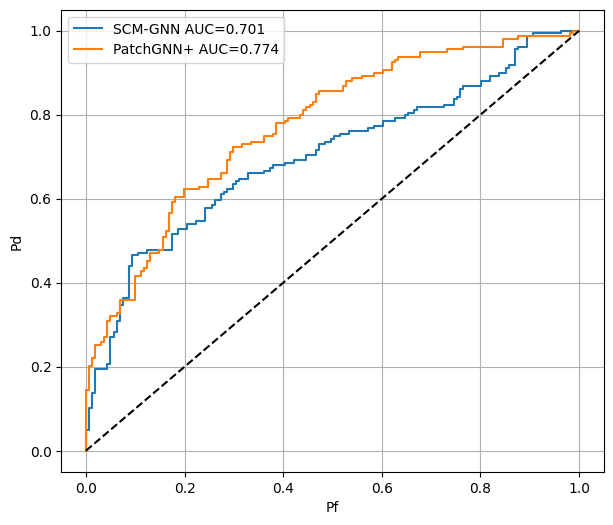

   SNR_dB  Pd_SCM_GNN  Pd_PatchGNN+
0     -10       0.250         0.225
1      -8       0.370         0.400
2      -6       0.480         0.400
3      -4       0.570         0.595
4      -2       0.775         0.815
5       0       0.840         0.925
6       2       0.890         0.975


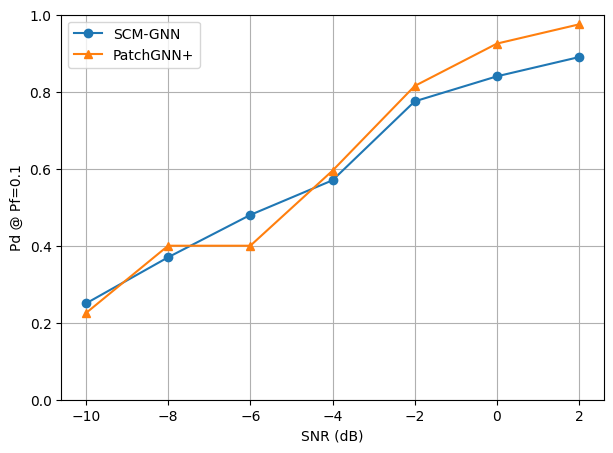

In [ ]:
import pandas as pd

# Helper: build patch graphs dataset (reuse windows created in Cell1)
# Build smaller train/test sets again but using same division already created
# We already have train_graphs/test_graphs for SCM-GNN (element-level).
# Build train/test for PatchGNNs using the same windows so datasets align.

# Build patch graphs (reuse signal_windows/noise_windows from Cell1)
patch_graphs = []
for w in signal_windows:
    Ry = compute_cov(w, zeta)
    g = build_patch_graph(Ry, patch_size_blocks, top_k, use_imag)
    g.y = torch.tensor([1], dtype=torch.long); patch_graphs.append(g)
for w in noise_windows:
    Ry = compute_cov(w, zeta)
    g = build_patch_graph(Ry, patch_size_blocks, top_k, use_imag)
    g.y = torch.tensor([0], dtype=torch.long); patch_graphs.append(g)
print("Patch graphs built:", len(patch_graphs))

# create same train/test split indices used in Cell1 for fairness
all_indices = np.arange(len(graphs))
# the 'perm' and split used in Cell1 are in the namespace; we re-use them
train_idx = perm[:split]
test_idx = perm[split:]

# map these indices into patch_graphs too (they are in the same order signal then noise)
train_patch_graphs = [patch_graphs[i] for i in train_idx]
test_patch_graphs  = [patch_graphs[i] for i in test_idx]

train_loader_patch = DataLoader(train_patch_graphs, batch_size=batch_size, shuffle=True)
test_loader_patch  = DataLoader(test_patch_graphs, batch_size=batch_size)

# Instantiate three models
# 1) SCM-GNN (already created as scm_gnn)
# If not defined in current namespace (user didn't run Cell1), create
try:
    scm_gnn
except NameError:
    scm_gnn = SCMGNN(in_feats).to(device)
    opt_scm = torch.optim.Adam(scm_gnn.parameters(), lr=lr, weight_decay=weight_decay)

# 2) PatchGNN
in_feats_patch = train_patch_graphs[0].x.shape[1]
patchgnn = SCM_PatchGNN(in_feats_patch, hidden=64, cheb_K=3, num_cheb=2, pool_ratio1=0.6, pool_ratio2=0.5).to(device)
opt_patch = torch.optim.Adam(patchgnn.parameters(), lr=lr, weight_decay=weight_decay)

# 3) PatchGNN+
patchgnn_plus = SCM_PatchGNN_plus(in_feats_patch, hidden=64, cheb_K=3).to(device)
opt_patch_plus = torch.optim.Adam(patchgnn_plus.parameters(), lr=lr, weight_decay=weight_decay)

# Training function generic
def train_model(model, loader, optimizer, epochs_local=20):
    best_auc = -1.0
    best_state = None
    for ep in range(1, epochs_local+1):
        model.train()
        total_loss = 0.0
        for batch in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            out = model(batch)
            loss = F.cross_entropy(out, batch.y.view(-1))
            loss.backward(); optimizer.step()
            total_loss += loss.item() * batch.num_graphs
        # eval
    return

# We'll run a short training for demo. Increase epochs for final runs.
train_epochs = 10  # set to 50 for final experiments (use available GPU/memory)
print("Training SCM-GNN...")
for ep in range(train_epochs):
    l = train_epoch(scm_gnn, train_loader, opt_scm)
    ys_scm, ps_scm = eval_model(scm_gnn, test_loader)
    aucs_scm = roc_auc_score(ys_scm, ps_scm) if len(np.unique(ys_scm))>1 else float('nan')
    print(f"[SCM-GNN] Ep {ep+1}/{train_epochs} loss {l:.4f} auc {aucs_scm:.4f}")

print("Training PatchGNN+...")
for ep in range(train_epochs):
    l = train_epoch(patchgnn_plus, train_loader_patch, opt_patch_plus)
    ys_p2, ps_p2 = eval_model(patchgnn_plus, test_loader_patch)
    auc_p2 = roc_auc_score(ys_p2, ps_p2) if len(np.unique(ys_p2))>1 else float('nan')
    print(f"[PatchGNN+] Ep {ep+1}/{train_epochs} loss {l:.4f} auc {auc_p2:.4f}")

# Final eval & comparison
ys_scm, ps_scm = eval_model(scm_gnn, test_loader)
ys_p, ps_p = eval_model(patchgnn, test_loader_patch)
ys_p2, ps_p2 = eval_model(patchgnn_plus, test_loader_patch)

print("Final AUCs -> SCM-GNN:", roc_auc_score(ys_scm, ps_scm), "PatchGNN+:", roc_auc_score(ys_p2, ps_p2))

# ROC comparison plot
fpr1,tpr1,_ = roc_curve(ys_scm, ps_scm)
fpr2,tpr2,_ = roc_curve(ys_p, ps_p)
fpr3,tpr3,_ = roc_curve(ys_p2, ps_p2)
plt.figure(figsize=(7,6)); plt.plot(fpr1,tpr1,label=f"SCM-GNN AUC={roc_auc_score(ys_scm,ps_scm):.3f}")
plt.plot(fpr3,tpr3,label=f"PatchGNN+ AUC={roc_auc_score(ys_p2,ps_p2):.3f}")
plt.plot([0,1],[0,1],'k--'); plt.xlabel("Pf"); plt.ylabel("Pd"); plt.legend(); plt.grid(); plt.show()

# Pd@Pf=0.1 (use the helper from earlier)
def compute_pd_at_pf(model, pf_target=0.1, snr_vals=list(range(-20,8,2)), num_windows=300):
    pd_res = {}
    for snr in snr_vals:
        H1 = create_windows(raw, num_windows, sample_size, snr)
        H0 = create_windows(raw, num_windows, sample_size, snr_db=None)
        H1_scores = get_scores_for_windows(model, H1, zeta, patch_size_blocks, top_k, use_imag) if model is not scm_gnn else get_scores_for_windows(model, H1, zeta, 1, top_k, use_imag)
        H0_scores = get_scores_for_windows(model, H0, zeta, patch_size_blocks, top_k, use_imag) if model is not scm_gnn else get_scores_for_windows(model, H0, zeta, 1, top_k, use_imag)
        ths = np.linspace(0,1,500)
        Pf_vals = [(H0_scores >= th).mean() for th in ths]
        idx = int(np.argmin(np.abs(np.array(Pf_vals) - pf_target)))
        th = ths[idx]
        Pd = (H1_scores >= th).mean()
        pd_res[snr] = Pd
    return pd_res

# Note: get_scores_for_windows expects patch-based graphs. For SCM-GNN we can use a wrapper:
def get_scores_for_windows(model, windows, zeta, patch_size_blocks, top_k, use_imag):
    scores=[]
    for w in windows:
        Ry = compute_cov(w, zeta)
        if isinstance(model, SCMGNN):
            g = covariance_to_graph(Ry, top_k=top_k, use_imag=use_imag)
        else:
            g = build_patch_graph(Ry, patch_size_blocks, top_k, use_imag)
        g.batch = torch.zeros(g.x.shape[0], dtype=torch.long)
        g = g.to(device)
        with torch.no_grad():
            out = model(g)
            prob = F.softmax(out, dim=1)[0,1].item()
        scores.append(prob)
    return np.array(scores)

# Compute Pd@Pf for each model (can be slow). Here run for fewer SNRs for demo:
demo_snrs = list(range(-10, 4, 2))
pd_scm = compute_pd_at_pf(scm_gnn, pf_target=0.1, snr_vals=demo_snrs, num_windows=200)

pd_patch_plus = compute_pd_at_pf(patchgnn_plus, pf_target=0.1, snr_vals=demo_snrs, num_windows=200)

df = pd.DataFrame({
    'SNR_dB': demo_snrs,
    'Pd_SCM_GNN': [pd_scm[s] for s in demo_snrs],
    'Pd_PatchGNN+':[pd_patch_plus[s] for s in demo_snrs]
})
print(df)
# Plot Pd vs SNR
plt.figure(figsize=(7,5))
plt.plot(df.SNR_dB, df.Pd_SCM_GNN, marker='o', label='SCM-GNN')
plt.plot(df.SNR_dB, df["Pd_PatchGNN+"], marker='^', label='PatchGNN+')
plt.xlabel("SNR (dB)")
plt.ylabel("Pd @ Pf=0.1")
plt.legend()
plt.grid()
plt.ylim([0,1])
plt.show()

